# **Homework 11**

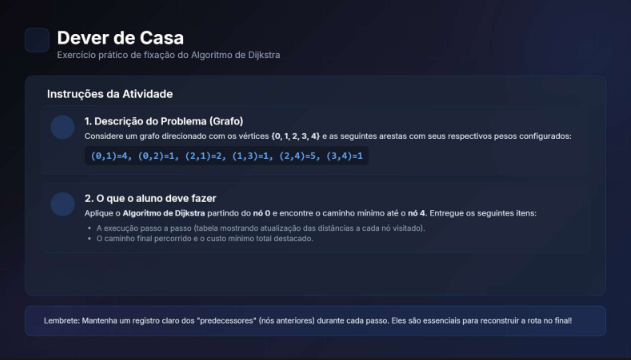



In [1]:
import heapq


def dijkstra(graph, start, target):
    """
    Computes the shortest path between two nodes using Dijkstra's algorithm.

    Parameters:
    graph (dict): A dictionary representing the adjacency list.
    start (int/str): The starting node.
    target (int/str): The destination node.

    Returns:
    tuple: (minimum_cost, shortest_path_list)
    """
    # Initialize all distances as infinite and the start node as 0.
    distances = {node: float("inf") for node in graph}
    distances[start] = 0

    # Track predecessors to reconstruct the final path later.
    predecessors = {node: None for node in graph}

    # Priority queue stores tuples in the format: (distance, current_node).
    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        # If a shorter path to this node was already processed, skip it.
        if current_distance > distances[current_node]:
            continue

        # Stop the search early if we have reached our destination.
        if current_node == target:
            break

        # Explore all unvisited neighbors of the current node.
        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            # Update the neighbor's distance if a shorter path is found.
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    # Reconstruct the shortest path by backtracking through predecessors.
    path = []
    step_node = target
    while step_node is not None:
        path.insert(0, step_node)
        step_node = predecessors[step_node]

    return distances[target], path


# Graph definition based on the homework assignment.
graph = {0: {1: 4, 2: 1}, 1: {3: 1}, 2: {1: 2, 4: 5}, 3: {4: 1}, 4: {}}

# Define the start and target nodes for execution.
start_node = 0
target_node = 4
min_cost, final_route = dijkstra(graph, start_node, target_node)

# Format and display the final results.
print(f"Minimum Total Cost: {min_cost}")
print(f"Shortest Path: {' -> '.join(map(str, final_route))}")

Minimum Total Cost: 5
Shortest Path: 0 -> 2 -> 1 -> 3 -> 4
